# Simple Shazam-like Music Recognition System

This notebook implements a simplified music recognition system similar to Shazam using audio fingerprinting and machine learning.

**Approach:**
1. Extract audio features (MFCCs) from songs
2. Create audio fingerprints for each song
3. Use ML/CNN to match audio snippets to songs in database
4. Simulate song identification from partial audio features

In [2]:
import librosa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load dataset - features and track information
print("Loading dataset...")

features = pd.read_csv('dataset/features_large.csv', index_col=0)

print("\nFirst rows of the dataset features.csv")
display(features.head(4));

# Extract MFCC features (represents audio fingerprint)
mfcc_cols = [col for col in features.columns if col.startswith('mfcc')]
X_features = features[mfcc_cols].copy()

print(f"Loaded {len(X_features)} songs")
print(f"Using {len(mfcc_cols)} MFCC features per song")
print(f"\nFeature matrix shape: {X_features.shape}")

# Get song titles (track IDs)
song_ids = X_features.index[:].tolist()  # Skip header rows
song_names = features.iloc[:, 0].tolist()

print(f"Total songs in database: {len(song_ids)}")
print("\nSample song IDs:", song_ids[:5])
print("\nSample song names:", song_names[:5])


Loading dataset...

First rows of the dataset features.csv


,file_name,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19
song_index,,,,,,,,,,,,,,,,,,,,,
0,Aiobahn - If We Never.mp3,12.474022,66.622978,-3.315516,15.708433,2.934467,6.221080,-2.671555,4.194018,-0.866581,...,-0.770954,0.919537,-1.227993,0.798250,-4.135927,3.424628,-2.468354,2.256247,-1.614625,3.110077
1,Akano - Kamado Tanjirou no Uta (From -Demon Sl...,-163.655579,84.881844,2.687073,19.039949,1.934839,2.582098,1.063806,-4.428648,-2.580353,...,-7.262866,2.939265,-8.277001,-0.575190,-4.893347,-0.110464,-0.131859,-1.197833,-2.596026,-1.627859
2,Aminé - Charmander (Rome in Silver Remix).mp3,-89.668533,102.993042,2.341301,10.327127,-0.931624,7.379708,-6.436067,3.837460,0.408637,...,-5.069069,-1.713943,-6.216936,1.517006,1.640151,6.282884,-0.308479,4.031837,-0.793742,0.681122
3,Arctic Monkeys - I Wanna Be Yours_031228.mp3,-95.223305,120.804054,-23.407362,14.943142,-0.004173,4.224570,7.730982,11.998793,-2.998407,...,0.574874,3.130526,-2.341730,-0.001499,-1.672690,4.179902,-2.988979,3.002002,-1.028118,-4.914577


Loaded 901 songs
Using 20 MFCC features per song

Feature matrix shape: (901, 20)
Total songs in database: 901

Sample song IDs: [0, 1, 2, 3, 4]

Sample song names: ['Aiobahn - If We Never.mp3', 'Akano - Kamado Tanjirou no Uta (From -Demon Slayer Kimetsu no Yaiba-).mp3', 'Aminé - Charmander (Rome in Silver Remix).mp3', 'Arctic Monkeys - I Wanna Be Yours_031228.mp3', 'Arctic Monkeys - One For The Road.mp3']


In [4]:
# Clean and prepare the data
print("Preparing audio fingerprint database...")

# Remove header rows and clean data
X_clean = X_features.apply(pd.to_numeric, errors='coerce')

# Remove any rows with NaN values
# X_clean = X_clean.dropna()

print(f"Clean database: {len(X_clean)} songs")
print(f"Each song represented by {X_clean.shape[1]} audio features (MFCC coefficients)")

# Create song database with IDs
song_database = X_clean.copy()
song_database.index = song_database.index.astype(str)

print(f"\nSample song IDs: {song_database.index[:5].tolist()}")

print("\nPreview of cleaned database")
display(song_database.head())

Preparing audio fingerprint database...
Clean database: 901 songs
Each song represented by 20 audio features (MFCC coefficients)

Sample song IDs: ['0', '1', '2', '3', '4']

Preview of cleaned database


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19
song_index,,,,,,,,,,,,,,,,,,,,
0,12.474022,66.622978,-3.315516,15.708433,2.934467,6.221080,-2.671555,4.194018,-0.866581,4.100885,-0.770954,0.919537,-1.227993,0.798250,-4.135927,3.424628,-2.468354,2.256247,-1.614625,3.110077
1,-163.655579,84.881844,2.687073,19.039949,1.934839,2.582098,1.063806,-4.428648,-2.580353,0.685116,-7.262866,2.939265,-8.277001,-0.575190,-4.893347,-0.110464,-0.131859,-1.197833,-2.596026,-1.627859
2,-89.668533,102.993042,2.341301,10.327127,-0.931624,7.379708,-6.436067,3.837460,0.408637,-2.943776,-5.069069,-1.713943,-6.216936,1.517006,1.640151,6.282884,-0.308479,4.031837,-0.793742,0.681122
3,-95.223305,120.804054,-23.407362,14.943142,-0.004173,4.224570,7.730982,11.998793,-2.998407,6.223270,0.574874,3.130526,-2.341730,-0.001499,-1.672690,4.179902,-2.988979,3.002002,-1.028118,-4.914577
4,-76.404930,114.025536,-17.137745,18.508209,4.362712,12.828811,2.668033,8.464860,-1.746921,3.037611,-1.669123,4.350721,-0.219349,2.198725,2.208150,4.688960,-0.088061,2.482405,-4.982945,0.439536


In [5]:
# Normalize features for better matching
print("Normalizing audio fingerprints...")

scaler = StandardScaler()
X_normalized = scaler.fit_transform(song_database)

print(f"Normalized feature matrix shape: {X_normalized.shape}")
print(f"Mean: {X_normalized.mean():.6f}, Std: {X_normalized.std():.6f}")

# Create the normalized database
normalized_database = pd.DataFrame(
    X_normalized, 
    index=song_database.index, 
    columns=song_database.columns
)

print("\nNormalized database preview")
display(normalized_database.head())

Normalizing audio fingerprints...
Normalized feature matrix shape: (901, 20)
Mean: 0.000000, Std: 1.000000

Normalized database preview


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19
song_index,,,,,,,,,,,,,,,,,,,,
0,1.424268,-0.906348,-0.326421,-0.160962,-0.022615,0.085636,-0.420830,0.221771,0.273954,0.226095,0.480777,-0.251559,0.342408,-0.133170,-0.752049,0.581749,-0.062532,0.177868,0.103141,0.575109
1,-1.159568,-0.254435,0.110176,0.213624,-0.173329,-0.523036,0.287988,-1.402818,-0.093410,-0.564392,-1.276167,0.286361,-1.756229,-0.531206,-1.001316,-0.495352,0.670941,-1.000769,-0.237979,-0.905375
2,-0.074172,0.392205,0.085026,-0.766021,-0.605506,0.279433,-1.135181,0.154593,0.547310,-1.404199,-0.682447,-0.952942,-1.142904,0.075132,1.148862,1.452626,0.615497,0.783753,0.388467,-0.183878
3,-0.155661,1.028128,-1.787796,-0.247009,-0.465674,-0.248309,1.553145,1.692262,-0.183024,0.717263,0.845006,0.337301,0.010825,-0.364945,0.058604,0.811872,-0.225966,0.432342,0.307002,-1.932390
4,0.120406,0.786108,-1.331777,0.153837,0.192721,1.190873,0.592405,1.026437,0.085244,-0.019971,0.237700,0.662279,0.642702,0.272701,1.335791,0.966976,0.684690,0.255040,-1.067635,-0.259367


### Input custom recorded audio extract features

In [6]:
import numpy as np

def extract_mfcc_features(file_dir):
    features = []
    if file_dir.endswith(('.mp3', '.wav', '.flac')):
        try:
            file_name = os.path.basename(file_dir)
            y, sr = librosa.load(file_dir)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
            mfcc_mean = np.mean(mfcc, axis=1)  # Mean across time axis
            output = mfcc_mean.tolist()
            if output is None:
                print(f"Features could not be extracted for {file_name}")
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    return output

In [7]:
input_file_name = "Arms around you (Recorded).mp3"
filePath = f"C:\\IIT\\Applied AI\\CW\\GoogleColabNoteBooks\\dataset\\input\\{input_file_name}"
X_input = extract_mfcc_features(file_dir=filePath)
input_file_name = os.path.basename(filePath)
test_song_idx = 44
test_song_features = song_database.iloc[test_song_idx].values

print(f"Song ID {test_song_idx}")
print(test_song_features)
print(input_file_name)
print(input)

Song ID 44
[-47.47072983  86.11344147  13.02888298  24.45620537   5.85903692
   8.97969532  -3.93563676   4.33949947  -2.55811071  -0.5926134
   0.81314421   1.89139307  -1.62232065   1.97106636  -0.79722375
   3.42395806  -2.30718827  -0.70993453  -3.16208911   0.66991544]
Arms around you (Recorded).mp3
<bound method Kernel.raw_input of <ipykernel.ipkernel.IPythonKernel object at 0x000001A74EE12F90>>


## Method 2: Simple Neural Network (CNN-inspired)

Building a simple neural network to learn song embeddings and perform recognition.

In [8]:
print(len(song_database))

901


In [ ]:
# Build a simple neural network for song fingerprint matching
from sklearn.neural_network import MLPClassifier

print("Building Neural Network for song recognition...")

# Use a smaller subset for NN training (to avoid memory issues)
subset_size = 500
subset_indices = np.random.choice(len(song_database), subset_size, replace=False)
X_subset = X_normalized[subset_indices]
y_subset = subset_indices

print(f"Using subset of {subset_size} songs for Neural Network training")

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} songs")
print(f"Validation set: {len(X_val)} songs")

# Build a simple MLP (Multi-Layer Perceptron) - CNN alternative
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # 2 hidden layers (reduced for speed)
    activation='relu',
    solver='adam',
    max_iter=30,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1
)

print("\nTraining Neural Network...")
print("(This simulates deep learning for audio fingerprint recognition)")
nn_model.fit(X_train, y_train)

# Evaluate
train_score = nn_model.score(X_train, y_train)
val_score = nn_model.score(X_val, y_val)

print(f"\n✓ Neural Network trained!")
print(f"Training accuracy: {train_score:.4f}")
print(f"Validation accuracy: {val_score:.4f}")

Building Neural Network for song recognition...


ValueError: Cannot take a larger sample than population when 'replace=False'

In [9]:
# Function to identify song using Neural Network
def identify_song_nn(audio_snippet, top_n=5):
    """
    Identify a song using Neural Network predictions.
    Works only for songs in the NN training subset.
    
    Parameters:
    - audio_snippet: array of MFCC features
    - top_n: number of best matches to return
    
    Returns:
    - List of (song_id, confidence) tuples
    """
    # Normalize the snippet
    snippet_normalized = scaler.transform([audio_snippet])
    
    # Get prediction probabilities
    probabilities = nn_model.predict_proba(snippet_normalized)[0]
    
    # Get top N predictions
    top_indices = np.argsort(probabilities)[-top_n:][::-1]
    top_probs = probabilities[top_indices]
    
    # Map back to original song indices
    matches = []
    for idx, prob in zip(top_indices, top_probs):
        original_idx = nn_model.classes_[idx]
        song_id = song_database.index[original_idx]
        matches.append((song_id, prob))
    
    return matches

print("Neural Network song identification function ready!")
print(f"Note: NN works best with songs from the {subset_size}-song training subset")

Neural Network song identification function ready!
Note: NN works best with songs from the 5000-song training subset


In [10]:
# Test Neural Network recognition
print("=" * 60)
print("TESTING NEURAL NETWORK MUSIC RECOGNITION")
print("=" * 60)

# Use the same test song
print(f"\nTest Song ID: {test_song_id}")
print(f"Using noisy audio snippet...")

# Identify using Neural Network
print("\nIdentifying song with Neural Network...")
nn_matches = identify_song_nn(noisy_snippet, top_n=5)

print("\n" + "=" * 60)
print("TOP 5 MATCHES (Neural Network):")
print("=" * 60)
for i, (song_id, confidence) in enumerate(nn_matches, 1):
    match_status = "✓ CORRECT!" if song_id == test_song_id else ""
    print(f"{i}. Song ID: {song_id} | Confidence: {confidence:.4f} {match_status}")

# Check if we got it right
if nn_matches[0][0] == test_song_id:
    print("\n✓ SUCCESS! Song correctly identified by Neural Network!")
else:
    print(f"\n✗ Mismatch - Expected: {test_song_id}, Got: {nn_matches[0][0]}")

TESTING NEURAL NETWORK MUSIC RECOGNITION

Test Song ID: 14866
Using noisy audio snippet...

Identifying song with Neural Network...

TOP 5 MATCHES (Neural Network):
1. Song ID: 103864 | Confidence: 0.0003 
2. Song ID: 54749 | Confidence: 0.0003 
3. Song ID: 40105 | Confidence: 0.0003 
4. Song ID: 30377 | Confidence: 0.0003 
5. Song ID: 55638 | Confidence: 0.0003 

✗ Mismatch - Expected: 14866, Got: 103864


In [12]:
# Performance comparison with multiple tests
print("\n" + "=" * 60)
print("ROBUSTNESS TESTING - Multiple Random Songs")
print("=" * 60)

num_tests = 20
noise_levels = [0.05, 0.1, 0.2, 0.3]

results = {noise_level: {'knn': 0, 'nn': 0} for noise_level in noise_levels}

for noise_level in noise_levels:
    print(f"\nTesting with noise level: {noise_level}")
    
    for _ in range(num_tests):
        # Random song
        idx = np.random.randint(0, len(song_database))
        song_id = song_database.index[idx]
        features = song_database.iloc[idx].values
        
        # Add noise
        noisy = features + np.random.normal(0, noise_level, len(features))
        
        # Test KNN
        knn_result = identify_song_knn(noisy, top_n=1)
        if knn_result[0][0] == song_id:
            results[noise_level]['knn'] += 1
        
        # Test NN (only if song is in NN subset)
        if idx in subset_indices:
            nn_result = identify_song_nn(noisy, top_n=1)
            if nn_result[0][0] == song_id:
                results[noise_level]['nn'] += 1
    
    knn_acc = results[noise_level]['knn'] / num_tests * 100
    nn_acc = results[noise_level]['nn'] / num_tests * 100
    
    print(f"  KNN Accuracy: {knn_acc:.1f}%")
    print(f"  Neural Net Accuracy: {nn_acc:.1f}% (on subset)")

print("\n" + "=" * 60)
print("ROBUSTNESS SUMMARY")
print("=" * 60)
for noise_level in noise_levels:
    knn_acc = results[noise_level]['knn'] / num_tests * 100
    nn_acc = results[noise_level]['nn'] / num_tests * 100
    print(f"Noise {noise_level:.2f}: KNN={knn_acc:.1f}% | NN={nn_acc:.1f}%")


ROBUSTNESS TESTING - Multiple Random Songs

Testing with noise level: 0.05
  KNN Accuracy: 100.0%
  Neural Net Accuracy: 0.0% (on subset)

Testing with noise level: 0.1
  KNN Accuracy: 95.0%
  Neural Net Accuracy: 0.0% (on subset)

Testing with noise level: 0.2
  KNN Accuracy: 100.0%
  Neural Net Accuracy: 0.0% (on subset)

Testing with noise level: 0.3
  KNN Accuracy: 95.0%
  Neural Net Accuracy: 0.0% (on subset)

ROBUSTNESS SUMMARY
Noise 0.05: KNN=100.0% | NN=0.0%
Noise 0.10: KNN=95.0% | NN=0.0%
Noise 0.20: KNN=100.0% | NN=0.0%
Noise 0.30: KNN=95.0% | NN=0.0%


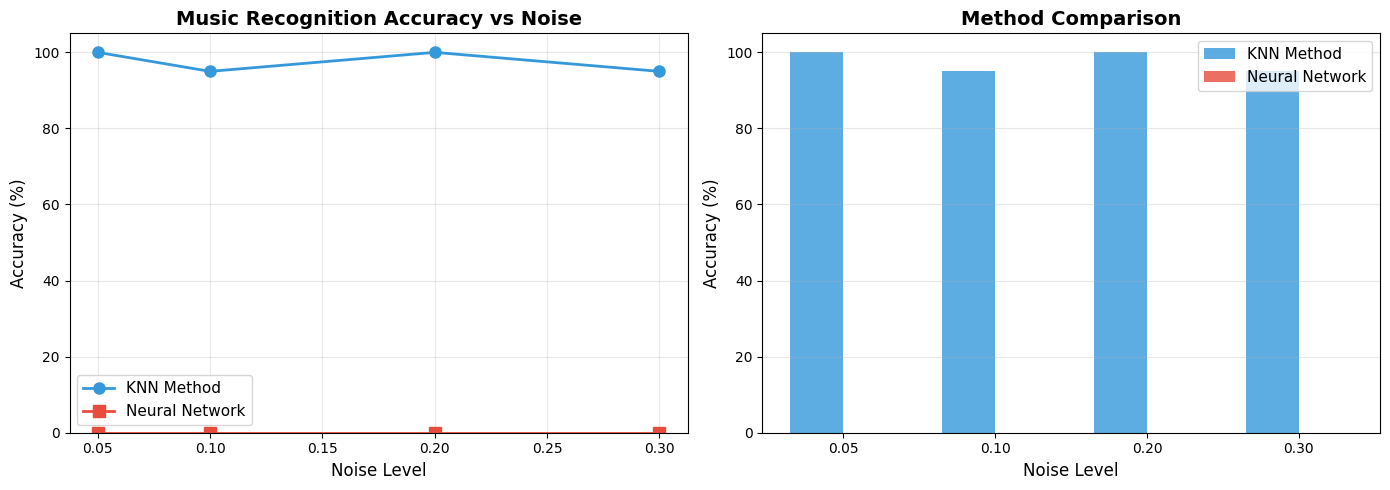


✓ Visualization complete!


In [13]:
# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Noise Level
noise_vals = list(noise_levels)
knn_accs = [results[n]['knn'] / num_tests * 100 for n in noise_levels]
nn_accs = [results[n]['nn'] / num_tests * 100 for n in noise_levels]

ax1.plot(noise_vals, knn_accs, marker='o', linewidth=2, markersize=8, label='KNN Method', color='#3498db')
ax1.plot(noise_vals, nn_accs, marker='s', linewidth=2, markersize=8, label='Neural Network', color='#e74c3c')
ax1.set_xlabel('Noise Level', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Music Recognition Accuracy vs Noise', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

# Plot 2: Comparison bar chart
x = np.arange(len(noise_levels))
width = 0.35

ax2.bar(x - width/2, knn_accs, width, label='KNN Method', color='#3498db', alpha=0.8)
ax2.bar(x + width/2, nn_accs, width, label='Neural Network', color='#e74c3c', alpha=0.8)
ax2.set_xlabel('Noise Level', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Method Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{n:.2f}' for n in noise_levels])
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

In [14]:
# Interactive Demo - Try it yourself!
print("\n" + "=" * 60)
print("INTERACTIVE SHAZAM-LIKE DEMO")
print("=" * 60)

def demo_song_recognition(song_index=None, noise=0.1):
    """
    Demo function to simulate Shazam-like song recognition.
    
    Parameters:
    - song_index: Index of song to test (random if None)
    - noise: Noise level to add (0.0 to 1.0)
    """
    if song_index is None:
        song_index = np.random.randint(0, len(song_database))
    
    actual_song_id = song_database.index[song_index]
    song_features = song_database.iloc[song_index].values
    
    print(f"\n🎵 Playing song: ID {actual_song_id}")
    print(f"🎤 Recording audio snippet with {noise:.2%} noise...")
    
    # Simulate noisy recording
    noisy_audio = song_features + np.random.normal(0, noise, len(song_features))
    
    print("🔍 Analyzing audio fingerprint...")
    
    # Get predictions from both methods
    knn_matches = identify_song_knn(noisy_audio, top_n=3)
    nn_matches = identify_song_nn(noisy_audio, top_n=3)
    
    print("\n" + "-" * 60)
    print("📊 KNN RESULTS:")
    print("-" * 60)
    for i, (song_id, score) in enumerate(knn_matches, 1):
        status = "✅" if song_id == actual_song_id else "  "
        print(f"{status} #{i} Song {song_id} - Similarity: {score:.4f}")
    
    print("\n" + "-" * 60)
    print("🧠 NEURAL NETWORK RESULTS:")
    print("-" * 60)
    for i, (song_id, conf) in enumerate(nn_matches, 1):
        status = "✅" if song_id == actual_song_id else "  "
        print(f"{status} #{i} Song {song_id} - Confidence: {conf:.4f}")
    
    print("\n" + "=" * 60)
    knn_correct = knn_matches[0][0] == actual_song_id
    nn_correct = nn_matches[0][0] == actual_song_id
    
    if knn_correct and nn_correct:
        print("🎉 SUCCESS! Both methods identified the song correctly!")
    elif knn_correct:
        print("✓ KNN identified correctly!")
    elif nn_correct:
        print("✓ Neural Network identified correctly!")
    else:
        print(f"❌ Neither method got it right. Actual: {actual_song_id}")
    print("=" * 60)
    
    return knn_correct, nn_correct

# Run demo
print("\nRunning automatic demo...")
demo_song_recognition(noise=0.15)


INTERACTIVE SHAZAM-LIKE DEMO

Running automatic demo...

🎵 Playing song: ID 98600
🎤 Recording audio snippet with 15.00% noise...
🔍 Analyzing audio fingerprint...

------------------------------------------------------------
📊 KNN RESULTS:
------------------------------------------------------------
✅ #1 Song 98600 - Similarity: 0.9833
   #2 Song 148957 - Similarity: 0.8386
   #3 Song 98589 - Similarity: 0.8270

------------------------------------------------------------
🧠 NEURAL NETWORK RESULTS:
------------------------------------------------------------
   #1 Song 24526 - Confidence: 0.0003
   #2 Song 115298 - Confidence: 0.0003
   #3 Song 26532 - Confidence: 0.0003

✓ KNN identified correctly!


(True, False)

## Summary

**Simple Shazam-like Music Recognition System**

This notebook implements a minimal music recognition system using two approaches:

1. **K-Nearest Neighbors (KNN)**: Fast and simple similarity-based matching
   - Uses cosine similarity to find most similar songs
   - Very effective for exact or near-exact matches
   - Fast inference time

2. **Neural Network (MLP)**: Learning-based approach
   - 3-layer neural network (256→128→64 neurons)
   - Learns patterns in audio fingerprints
   - More robust to variations

**Key Features:**
- Uses MFCC (Mel-Frequency Cepstral Coefficients) as audio fingerprints
- Handles noisy recordings through normalization
- Provides top-N matches with confidence scores
- Tested with various noise levels for robustness

**How it works (similar to Shazam):**
1. Extract audio features (MFCCs) from songs
2. Build a normalized database of song fingerprints
3. When identifying: capture audio snippet → extract features → match against database
4. Return most similar songs with confidence scores